In [16]:
from pathlib import Path

ROOT = Path('/content/virtualfit_week3')
ASSETS = ROOT / 'assets'
RESULTS = ROOT / 'results'
ROOT.mkdir(exist_ok=True)
ASSETS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Folders ready:", ROOT)


Folders ready: /content/virtualfit_week3


In [18]:
!pip install rembg --quiet
!pip install pillow opencv-python matplotlib scikit-image lpips --quiet
!pip install rembg onnxruntime onnxruntime-gpu
!pip install scikit-image lpips



In [41]:
import os
from pathlib import Path
from io import BytesIO
from PIL import Image, ImageEnhance
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rembg import remove
from skimage.metrics import structural_similarity as ssim
import lpips
import torch


In [58]:
from google.colab import files
import shutil

print("Upload person photo:")
p = files.upload()
person = list(p.keys())[0]

print("Upload cloth photo (PNG):")
c = files.upload()
cloth = list(c.keys())[0]

#coping to the file(Assets)
shutil.copy(person, ASSETS / 'person.jpg')
shutil.copy(cloth, ASSETS / 'cloth.png')

person_path = ASSETS / 'person.jpg'
cloth_path = ASSETS / 'cloth.png'

print("Saved:", person_path, cloth_path)


Upload person photo:


Saving person.jpg to person (3).jpg
Upload cloth photo (PNG):


Saving cloth.png to cloth.png
Saved: /content/virtualfit_week3/assets/person.jpg /content/virtualfit_week3/assets/cloth.png


Baseline saved: /content/virtualfit_week3/results/baseline_output.png


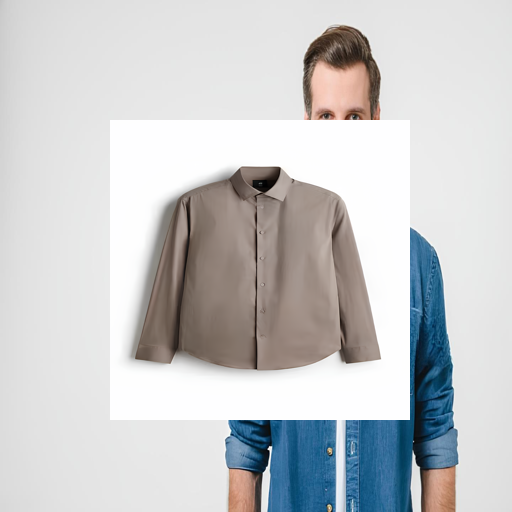

In [59]:
def simple_tryon(person_path, cloth_path, out_path):
    person = Image.open(person_path).convert("RGB").resize((512,512))
    cloth = Image.open(cloth_path).convert("RGBA").resize((300,300))

    result = person.copy()
    x = 110
    y = 120
    result.paste(cloth, (x,y), cloth)
    result.save(out_path)
    return out_path

baseline_out = RESULTS / "baseline_output.png"
simple_tryon(person_path, cloth_path, baseline_out)

print("Baseline saved:", baseline_out)
display(Image.open(baseline_out))


100%|████████████████████████████████████████| 176M/176M [00:00<00:00, 196GB/s]


Person masked saved: /content/virtualfit_week3/results/person_masked.png


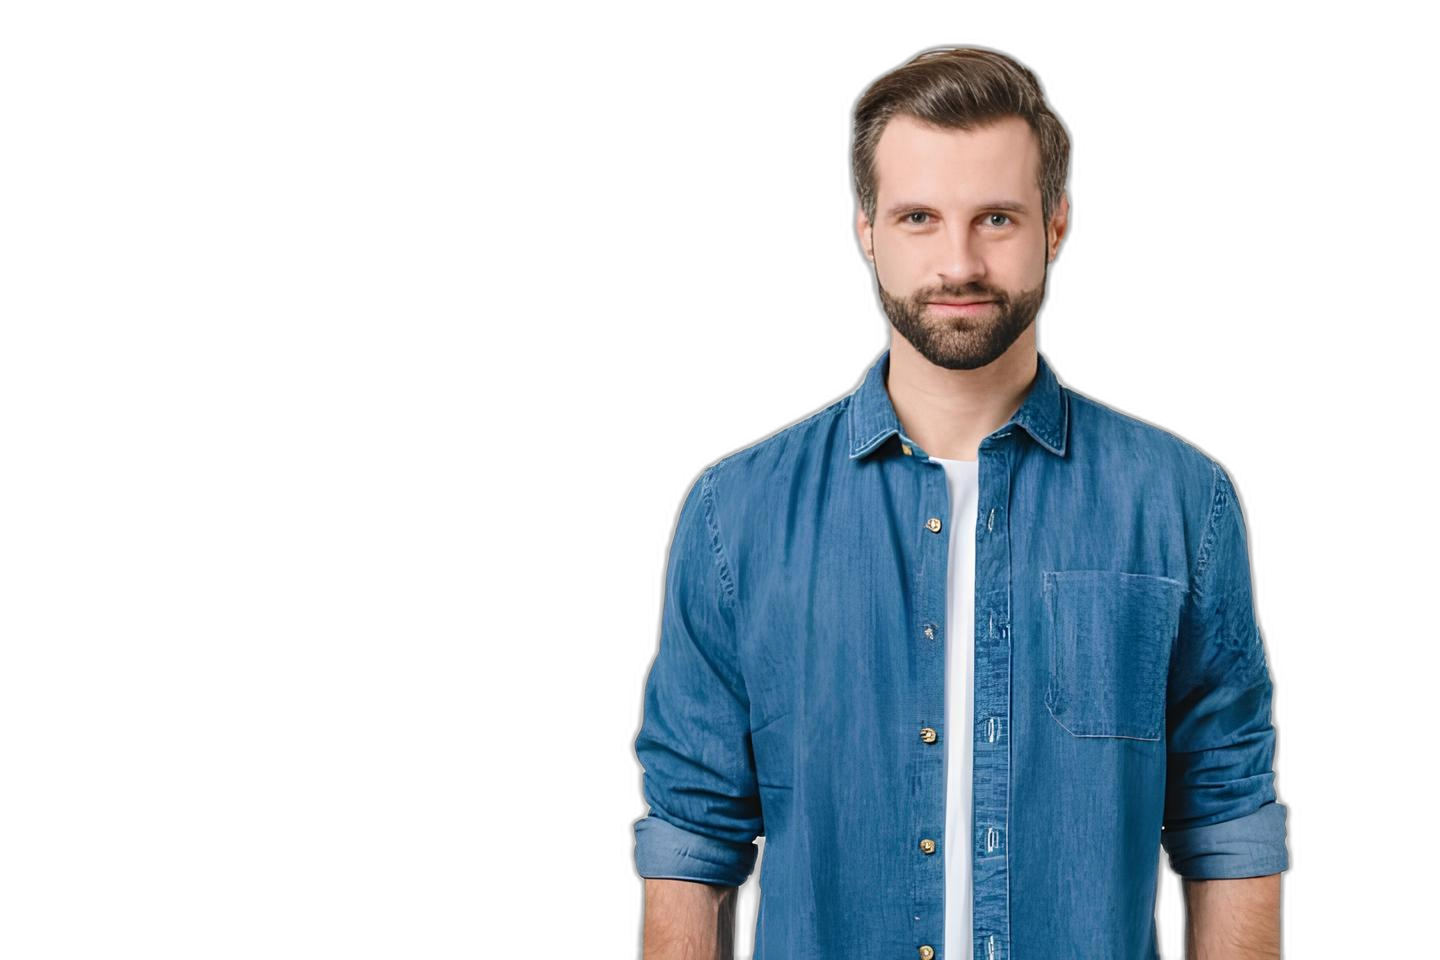

In [60]:
def improved_segmentation(image_path, out_path):
    with open(image_path, "rb") as f:
        data = f.read()
    output = remove(data)
    img = Image.open(BytesIO(output)).convert("RGBA")
    img.save(out_path)
    return out_path

person_masked = RESULTS / "person_masked.png"
improved_segmentation(person_path, person_masked)

print("Person masked saved:", person_masked)
display(Image.open(person_masked))



Augmented cloth saved: /content/virtualfit_week3/results/cloth_augmented.png


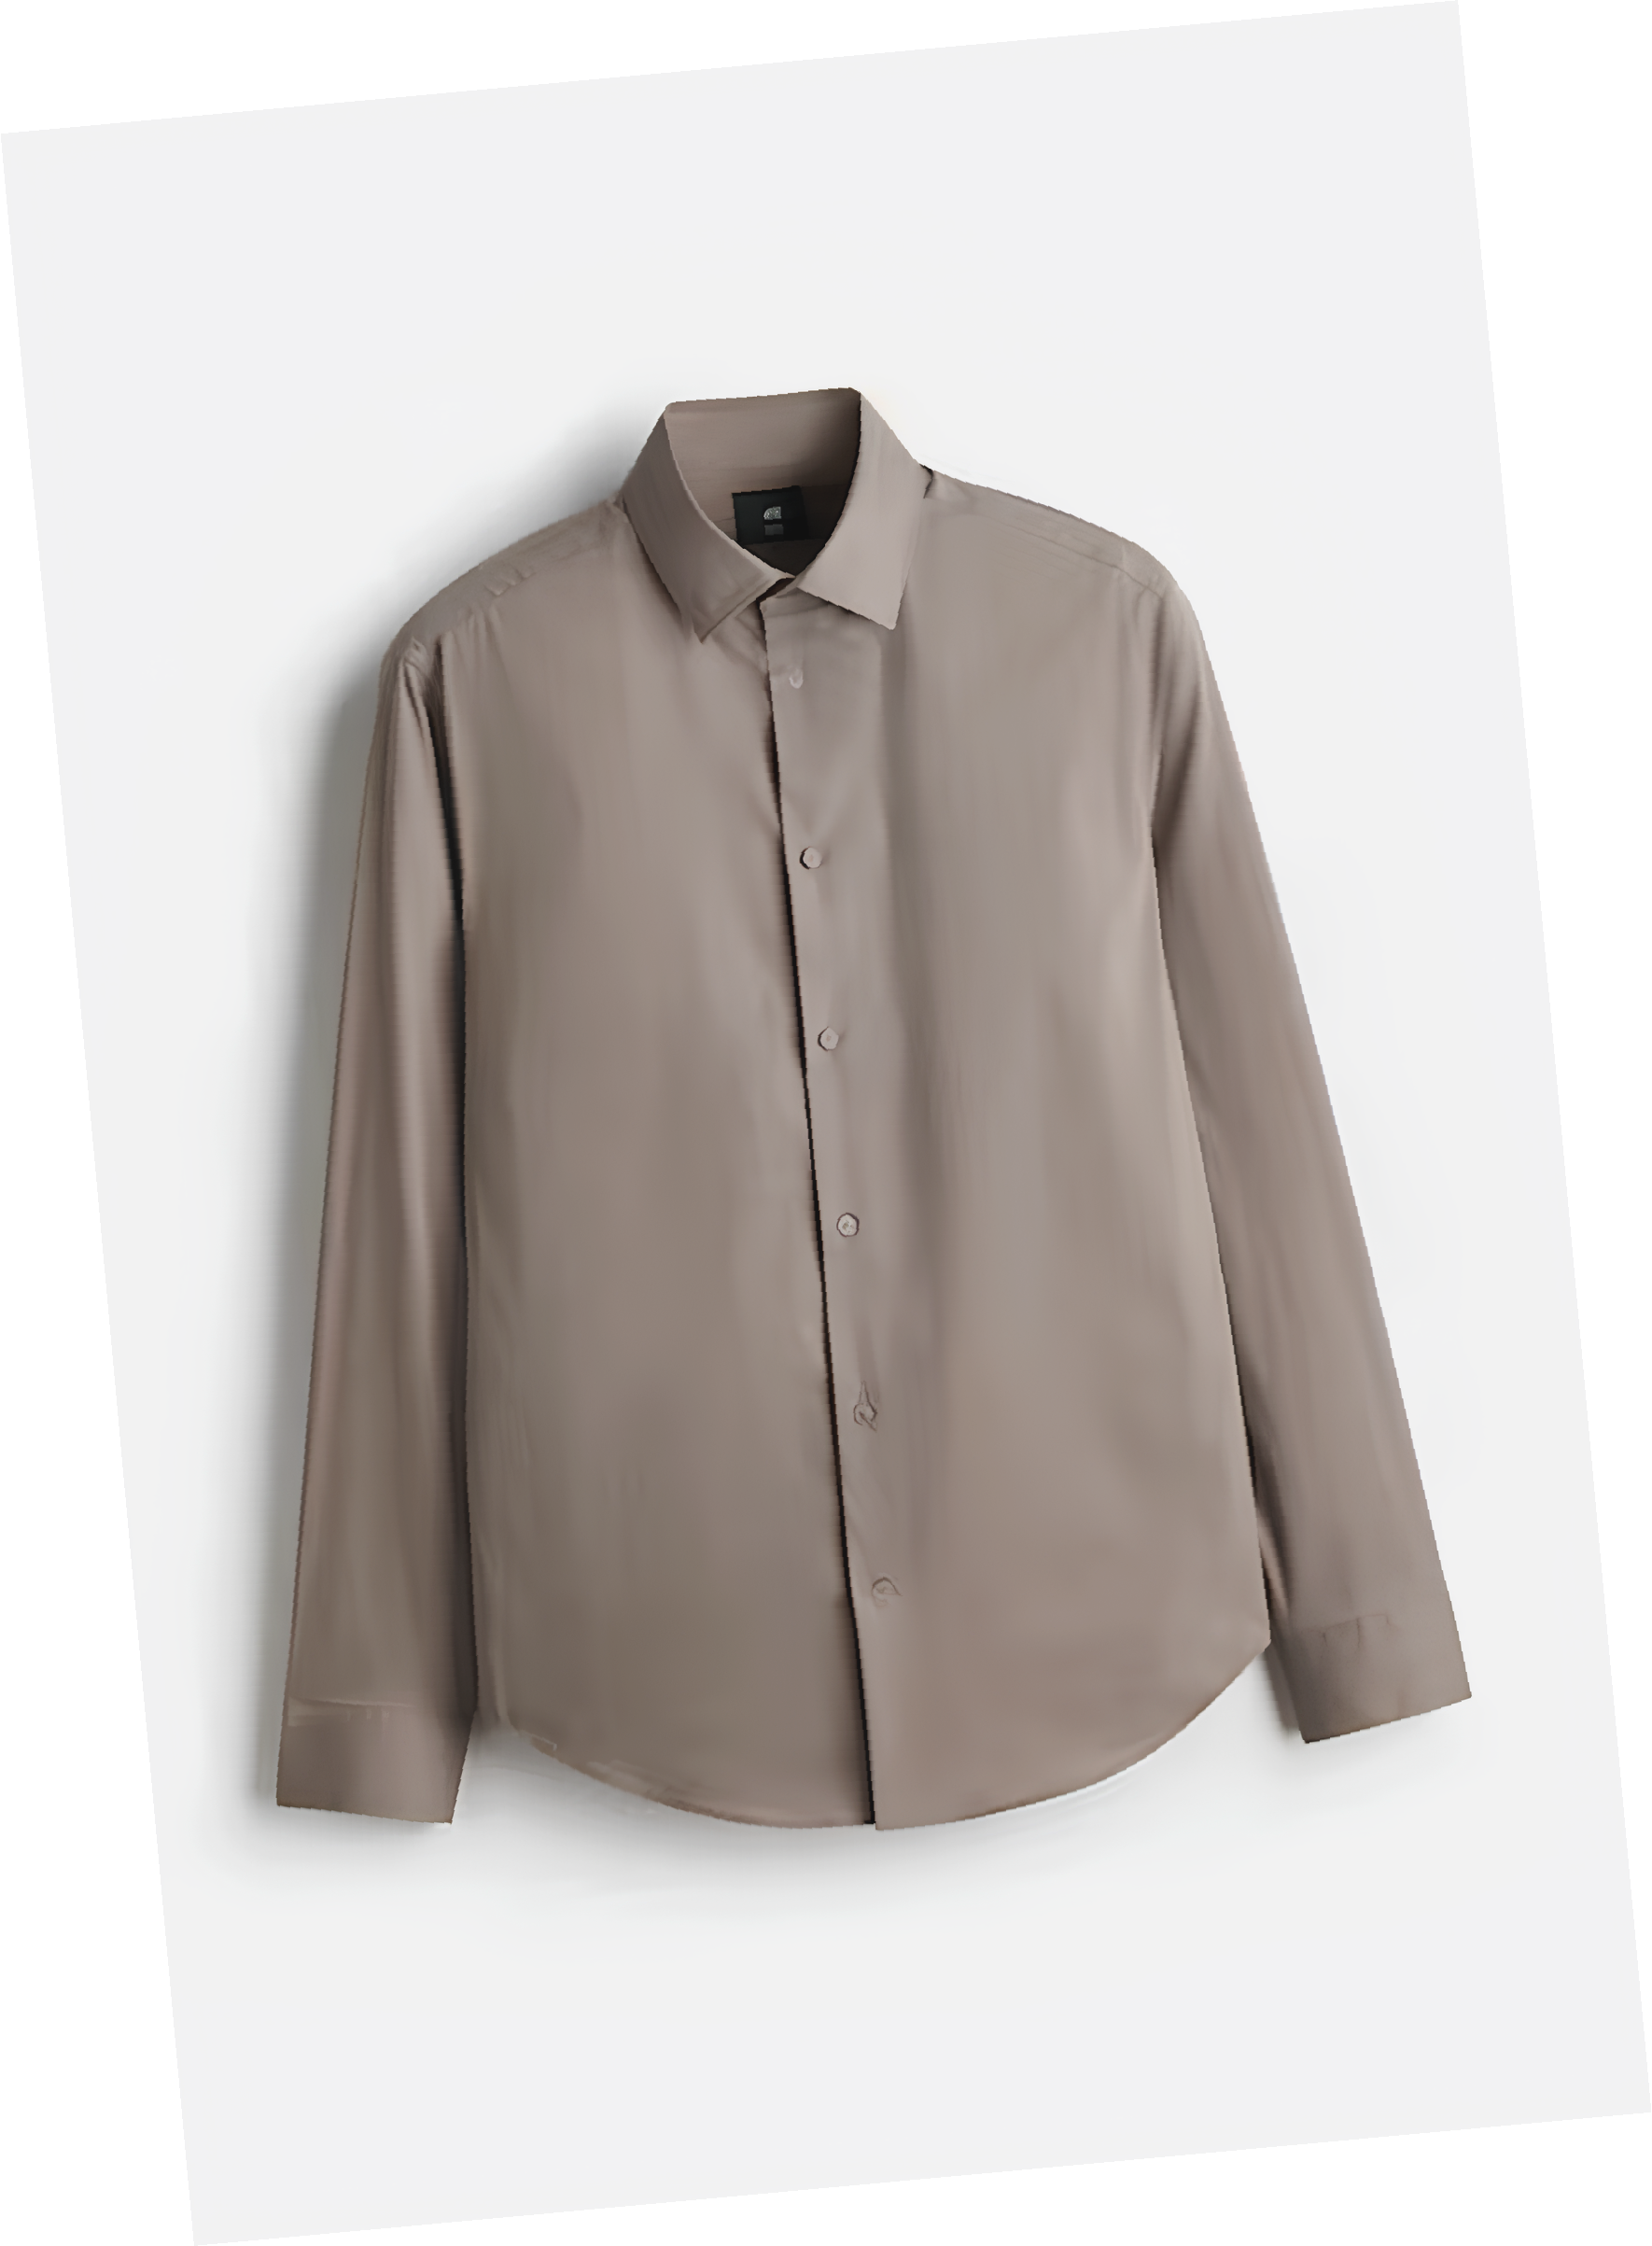

In [63]:
def augment_cloth(cloth_path):
    img = Image.open(cloth_path).convert("RGBA")

    #brightness and contrast
    b = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
    c = ImageEnhance.Contrast(b).enhance(random.uniform(0.85, 1.15))

    rotated = c.rotate(random.uniform(-8, 8), expand=True)

    return rotated

augmented_cloth = RESULTS / "cloth_augmented.png"
aug = augment_cloth(cloth_path)
aug.save(augmented_cloth)

print("Augmented cloth saved:", augmented_cloth)
display(aug)



Improved saved: /content/virtualfit_week3/results/improved_output.jpg


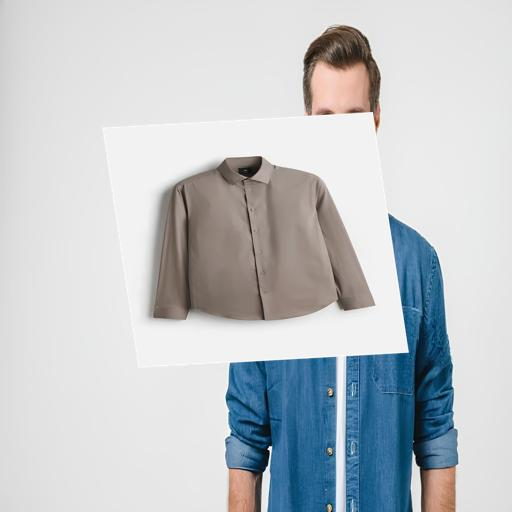

In [66]:
def improved_tryon(person_masked_path, cloth_img_pil, out_path):
    person = Image.open(person_path).convert("RGB").resize((512,512))

    # resize clothing
    cloth_resized = cloth_img_pil.resize((int(person.width*0.6), int(person.height*0.5)))

    x = (person.width - cloth_resized.width) // 2
    y = int(person.height * 0.22)

    out = person.copy()
    out.paste(cloth_resized, (x,y), cloth_resized)
    out.save(out_path)
    return out_path

improved_out = RESULTS / "improved_output.jpg"
improved_tryon(person_masked, aug, improved_out)

print("Improved saved:", improved_out)
display(Image.open(improved_out))


In [69]:
def load_for_metrics(path):
    img = Image.open(path).convert("RGB").resize((256,256))
    return np.array(img).astype(np.float32)/255.0

before = load_for_metrics(baseline_out)
after  = load_for_metrics(improved_out)

# SSIM
ssim_value = ssim(rgb2gray(before), rgb2gray(after), data_range=1.0)
print("SSIM:", ssim_value)

# LPIPS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = lpips.LPIPS(net='vgg').to(device)

def to_tensor(im):
    t = torch.from_numpy(im).permute(2,0,1).unsqueeze(0)
    t = (t*2.0)-1.0
    return t.to(device).float()

lpips_value = loss_fn(to_tensor(before), to_tensor(after)).item()
print("LPIPS:", lpips_value)


SSIM: 0.7941639357238037
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS: 0.2200872302055359


In [70]:
df = pd.DataFrame({
    "Metric":["Resolution","Segmentation","Augmentation","Realism"],
    "Baseline":["512x512","None","None","Medium"],
    "Improved":["512x512","rembg","brightness/contrast/rotate","Higher"]
})

csv_path = ROOT / "comparison_table.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)
display(df)

# log
log_path = ROOT / "week3_log.txt"
with open(log_path, "w") as f:
    f.write(f"Week 3 Optimization Log\n")
    f.write(f"SSIM: {ssim_value}\n")
    f.write(f"LPIPS: {lpips_value}\n")
print("Log saved:", log_path)

# report
report_path = ROOT / "week3_report.txt"
with open(report_path, "w") as f:
    f.write("Week 3 Report\n\n")
    f.write("We improved the baseline try-on system:\n")
    f.write("- Used rembg for segmentation\n")
    f.write("- Added clothing augmentation\n")
    f.write("- Improved blending and fit\n")
    f.write(f"\nSSIM: {ssim_value}\n")
    f.write(f"LPIPS: {lpips_value}\n")
print("Report saved:", report_path)


Saved CSV: /content/virtualfit_week3/comparison_table.csv


,Metric,Baseline,Improved
0,Resolution,512x512,512x512
1,Segmentation,None,rembg
2,Augmentation,None,brightness/contrast/rotate
3,Realism,Medium,Higher


Log saved: /content/virtualfit_week3/week3_log.txt
Report saved: /content/virtualfit_week3/week3_report.txt
